In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("superstore_final_dataset.csv",encoding="latin1") 


# 1. Check data dimensions and information
print(df.info())

# 2. Handle missing values (Postal Code usually has 11 nulls)
df['City'] = df['City'].fillna('Unknown')

# 3. Convert date features to datetime objects
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d/%m/%Y', errors='coerce')
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], format='%d/%m/%Y', errors='coerce')

# Drop completely duplicated rows if any exist
df.drop_duplicates(inplace=True)

print("Data cleaning completed successfully!")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [11]:
# Assuming a standard simulated gross baseline profit margin of 15% for evaluation if missing
if 'Profit' not in df.columns:
    df['Profit'] = df['Sales'] * 0.15 

# Calculate Key Business KPIs
total_revenue = df['Sales'].sum()
total_profit = df['Profit'].sum()
overall_profit_margin = (total_profit / total_revenue) * 100
average_order_value = df.groupby('Order_ID')['Sales'].sum().mean()

# Output the high-level KPI dashboard metrics
print(f"--- CORE EXECUTIVE METRICS ---")
print(f"Total Revenue Generated: ${total_revenue:,.2f}")
print(f"Total Profit Accrued: ${total_profit:,.2f}")
print(f"Net Profit Margin percentage: {overall_profit_margin:.2f}%")
print(f"Average Order Value (AOV): ${average_order_value:,.2f}")

--- CORE EXECUTIVE METRICS ---
Total Revenue Generated: $2,261,536.78
Total Profit Accrued: $339,230.52
Net Profit Margin percentage: 15.00%
Average Order Value (AOV): $459.48


C:\Users\vaibh\AppData\Local\Temp\ipykernel_13696\1146234796.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regional_performance, x='Region', y='Sales', palette='Blues_r', ax=axes[1])


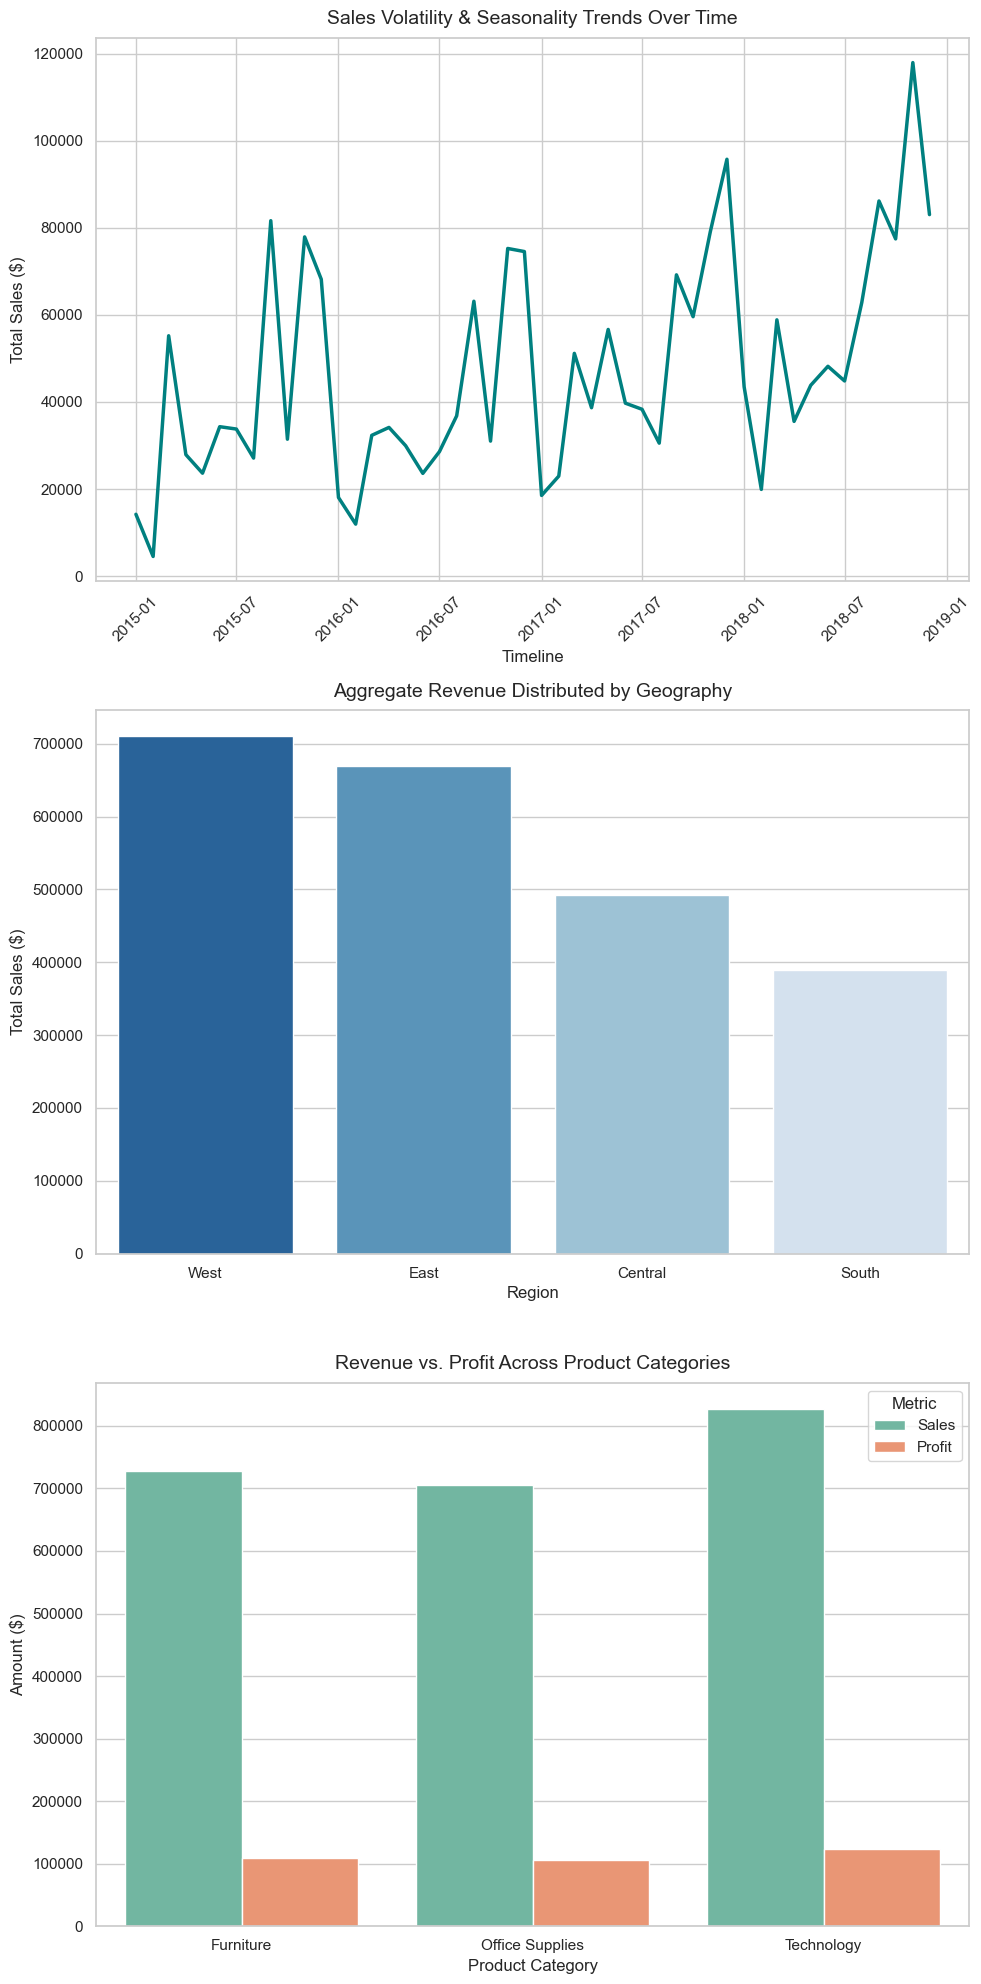

In [31]:
# Extract time elements for Seasonality Analysis
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.to_period('M')
df['Month_Name'] = df['Order_Date'].dt.strftime('%B')


sns.set_theme(style="whitegrid")

# Create a tall figure to accommodate 4 distinct plots vertically (scrolling format)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 20))

# 1. Visualization: Temporal Seasonality Trend (Sales over time)
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].dt.to_timestamp()
sns.lineplot(data=monthly_sales, x='Month', y='Sales', color='teal', linewidth=2.5, ax=axes[0])
axes[0].set_title('Sales Volatility & Seasonality Trends Over Time', fontsize=14, pad=10)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xlabel('Timeline')
axes[0].set_ylabel('Total Sales ($)')

# 2. Visualization: Spatial Distribution (Regional Performance)
regional_performance = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=regional_performance, x='Region', y='Sales', palette='Blues_r', ax=axes[1])
axes[1].set_title('Aggregate Revenue Distributed by Geography', fontsize=14, pad=10)
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Total Sales ($)')

# 3. Visualization: Categorical Segmentation 
category_performance = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
category_melted = pd.melt(category_performance, id_vars=['Category'], value_vars=['Sales', 'Profit'], 
                          var_name='Metric', value_name='Amount')
sns.barplot(data=category_melted, x='Category', y='Amount', hue='Metric', palette='Set2', ax=axes[2])
axes[2].set_title('Revenue vs. Profit Across Product Categories', fontsize=14, pad=10)
axes[2].set_xlabel('Product Category')
axes[2].set_ylabel('Amount ($)')

plt.tight_layout()
plt.savefig('sales_performance_charts.png', dpi=300)
plt.show()



C:\Users\vaibh\AppData\Local\Temp\ipykernel_13696\680548202.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='Sales', y='Product_Name', palette='viridis', ax=ax)


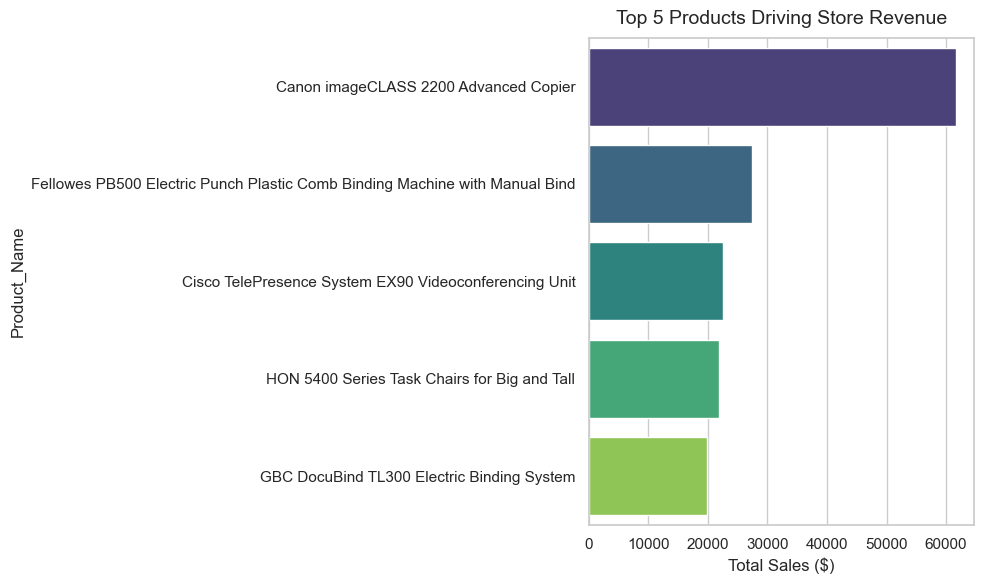


--- BOTTOM 5 WORST PERFORMING PRODUCTS BY REVENUE ---
                                        Product_Name  Sales
0  Eureka Disposable Bags for Sanitaire Vibra Gro...  1.624
1                                            Avery 5  5.760
2                                           Xerox 20  6.480
3                                Grip Seal Envelopes  7.072
4                  Acme Serrated Blade Letter Opener  7.632


 --- TASK COMPLETE ---


In [39]:
sns.set_theme(style="whitegrid")

# Create a tall figure to accommodate  distinct plots vertically (scrolling format)
fig, ax = plt.subplots(figsize=(10, 6))

# 4. Visualization: Top 5 Best Performing Products
top_products = df.groupby('Product_Name')['Sales'].sum().nlargest(5).reset_index()
sns.barplot(data=top_products, x='Sales', y='Product_Name', palette='viridis', ax=ax)
ax.set_title('Top 5 Products Driving Store Revenue', fontsize=14, pad=10)
ax.set_xlabel('Total Sales ($)')
ax.set_ylabel('Product_Name')

# Automatically adjust spacing to prevent overlapping titles/labels
plt.tight_layout()
plt.savefig('sales_performance_charts.png', dpi=300)
plt.show()

# Identify Lowest Performing Items
worst_products = df.groupby('Product_Name')['Sales'].sum().nsmallest(5).reset_index()
print("\n--- BOTTOM 5 WORST PERFORMING PRODUCTS BY REVENUE ---")
print(worst_products)
print("\n\n --- TASK COMPLETE ---")

In [40]:
df.to_csv("tableau_data.csv",index=False)